In [ ]:
# 1. تثبيت الأدوات والمكتبات المطلوبة
!apt-get install -y poppler-utils
!pip install pdf2image easyocr

import os
import cv2
import numpy as np
import csv
import easyocr
from google.colab import drive
from pdf2image import convert_from_path
from google.colab.patches import cv2_imshow
from PIL import Image

# تهيئة قارئ النصوص (إنجليزي)
reader = easyocr.Reader(['en'])

# ربط جوجل درايف
drive.mount('/content/drive')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 61.0 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=5291ef2d778a1f6653a2d4b30c17e765d62f58e30d230b5f5b863073a8f93fb2
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


Progress: |██████████████████████████████████████████████████| 100.0% CompleteDrive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# إعدادات المسارات
pdf_path = '/content/drive/MyDrive/python notes.pdf'
output_dir = '/content/drive/MyDrive/Handwriting_Dataset'
pages_to_process = 5
dpi_value = 300

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# تحويل PDF إلى صور (محدد بـ 5 صفحات فقط لتجنب الانهيار)
print(f"جاري تحويل أول {pages_to_process} صفحات بدقة {dpi_value} DPI...")
images = convert_from_path(pdf_path, dpi=dpi_value, first_page=1, last_page=pages_to_process)
print(f"✅ تم تحويل {len(images)} صفحات بنجاح.")

جاري تحويل أول 5 صفحات بدقة 300 DPI...
✅ تم تحويل 5 صفحات بنجاح.


### 2.1. إعداد قاعدة بيانات SQLite لتخزين الصور والنصوص

In [ ]:
import sqlite3

# تحديد مسار قاعدة البيانات SQLite
sqlite_db_path = os.path.join(output_dir, 'handwriting_data.db')

def setup_sqlite_db(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    # إنشاء جدول لتخزين البيانات:
    # - image_id: معرف فريد لكل صورة
    # - image_data: بيانات الصورة كـ BLOB (ثنائي)
    # - predicted_text: النص المستخرج بواسطة OCR
    # - status: حالة التضمين (yes/no)
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS handwriting_data (
            image_id INTEGER PRIMARY KEY AUTOINCREMENT,
            image_data BLOB NOT NULL,
            predicted_text TEXT,
            status TEXT
        )
    ''')
    conn.commit()
    conn.close()
    print(f"✅ تم إعداد قاعدة بيانات SQLite في: {db_path}")

# تشغيل إعداد قاعدة البيانات
setup_sqlite_db(sqlite_db_path)

✅ تم إعداد قاعدة بيانات SQLite في: /content/drive/MyDrive/Handwriting_Dataset/handwriting_data.db


Processing Page 1...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

تم استخراج وحفظ 71 سجلات من هذه الصفحة في قاعدة البيانات.


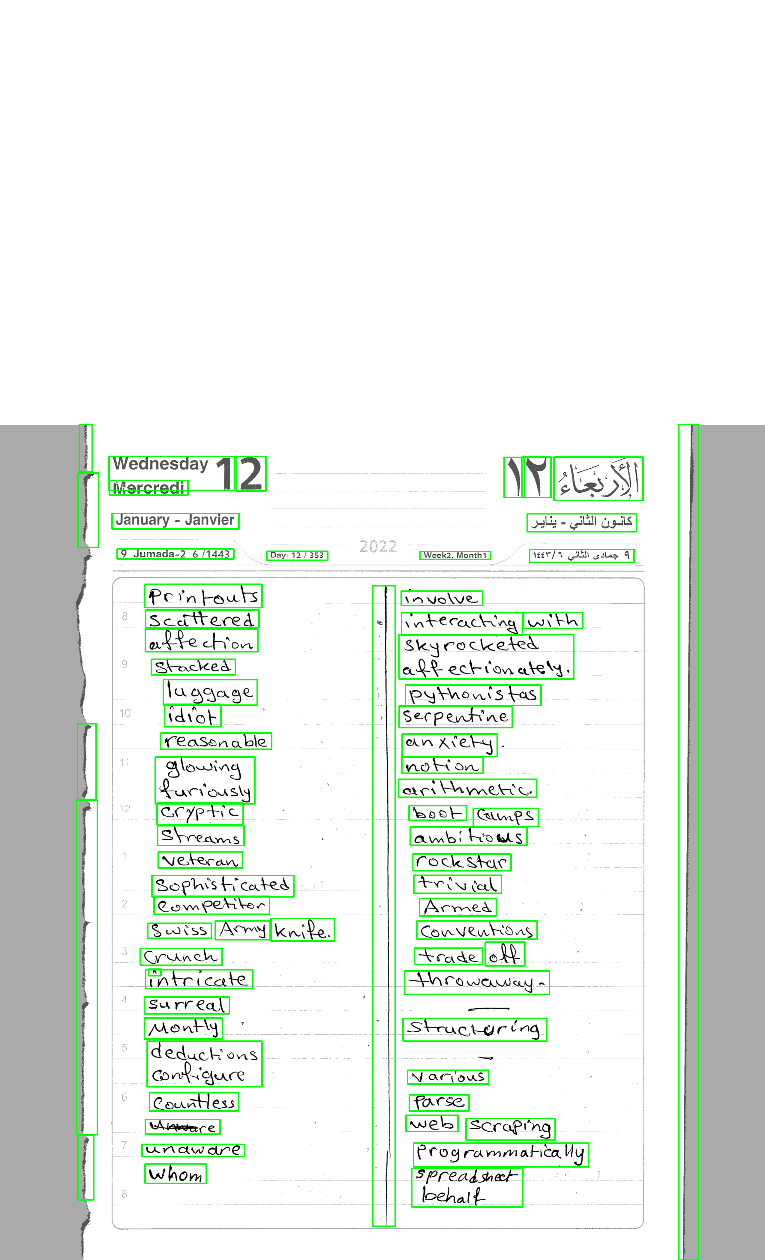

Processing Page 2...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

تم استخراج وحفظ 91 سجلات من هذه الصفحة في قاعدة البيانات.


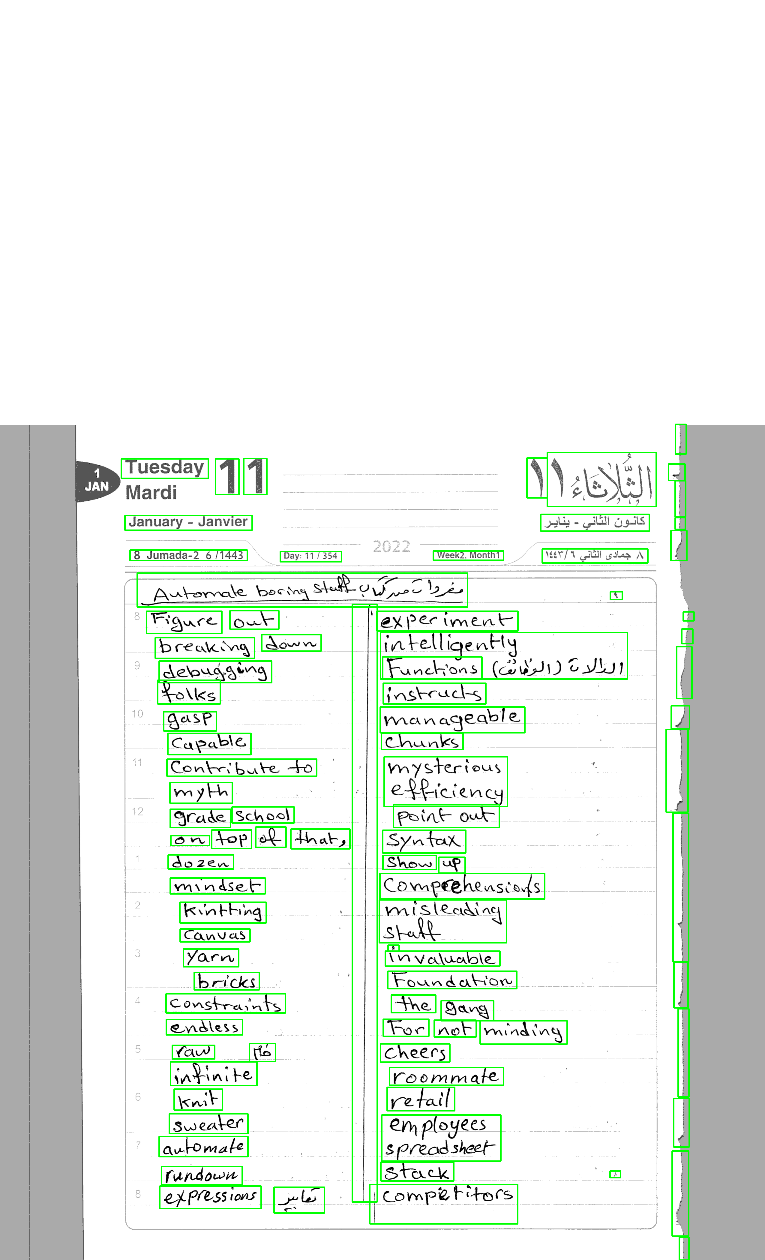

Processing Page 3...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

تم استخراج وحفظ 121 سجلات من هذه الصفحة في قاعدة البيانات.


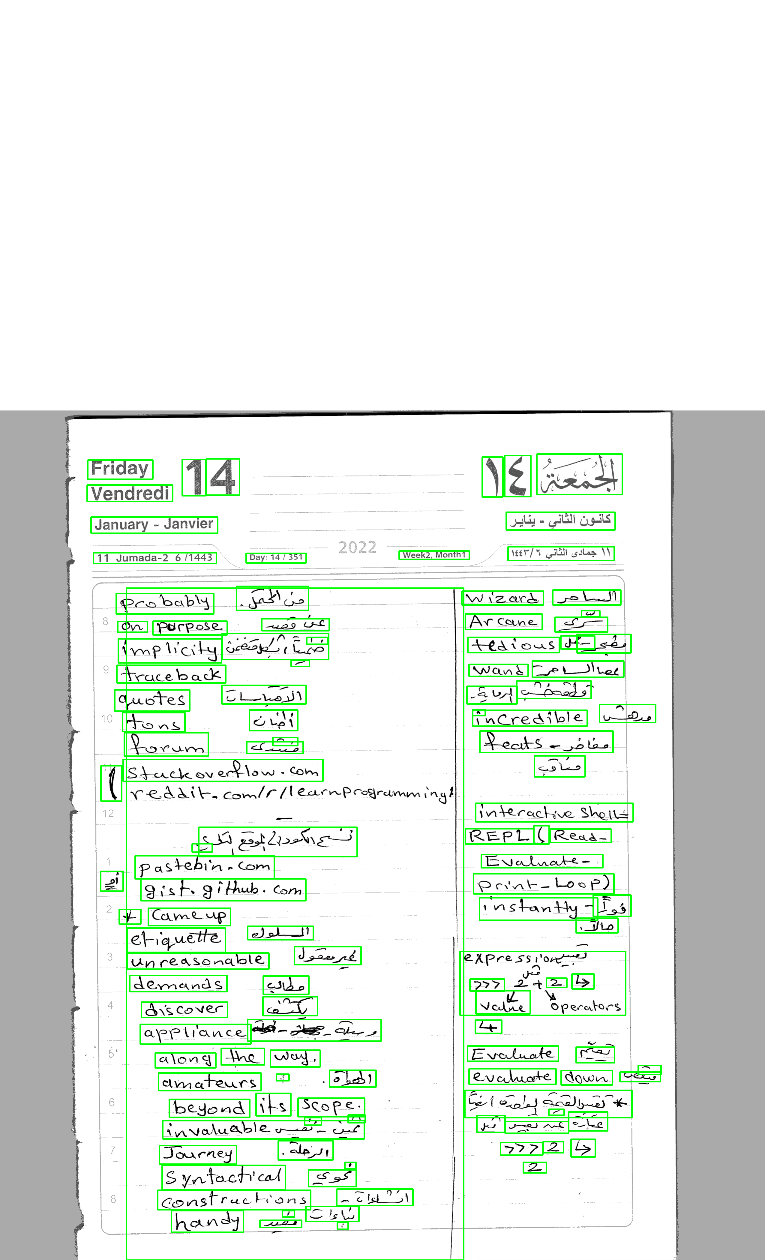

Processing Page 4...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

تم استخراج وحفظ 139 سجلات من هذه الصفحة في قاعدة البيانات.


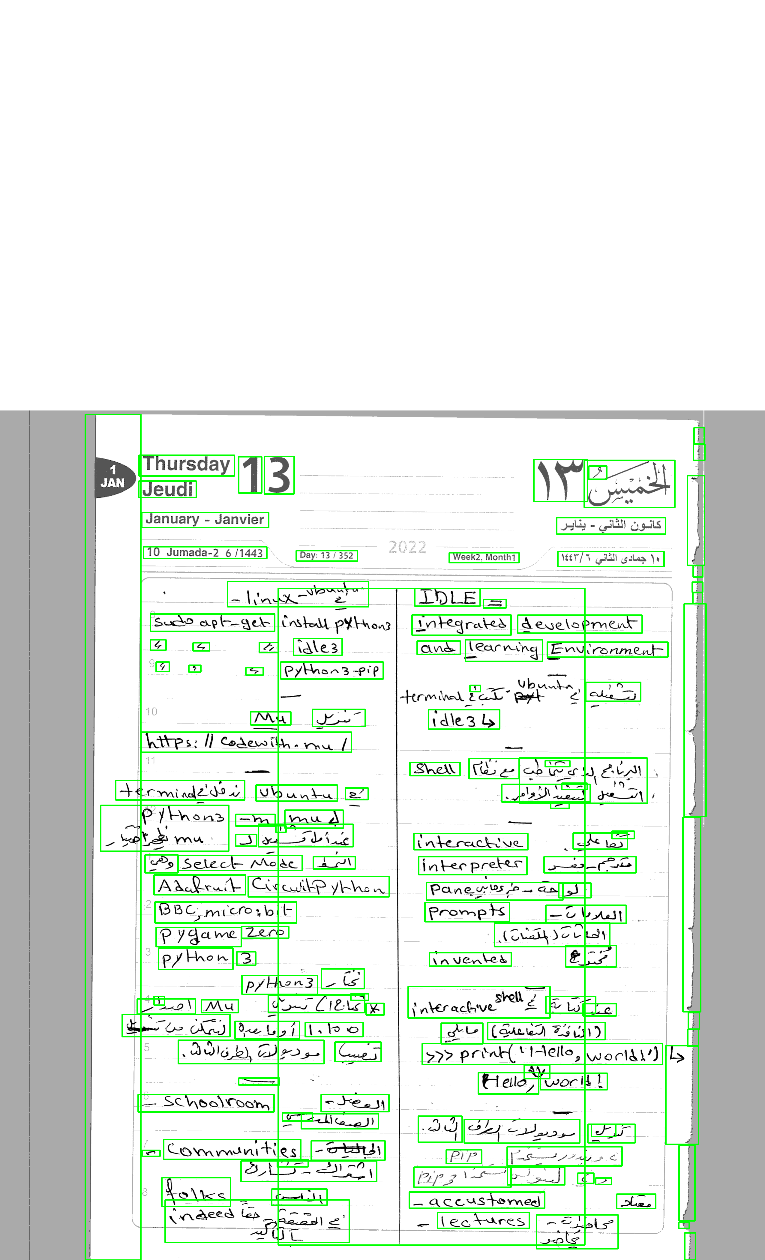

Processing Page 5...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

تم استخراج وحفظ 133 سجلات من هذه الصفحة في قاعدة البيانات.


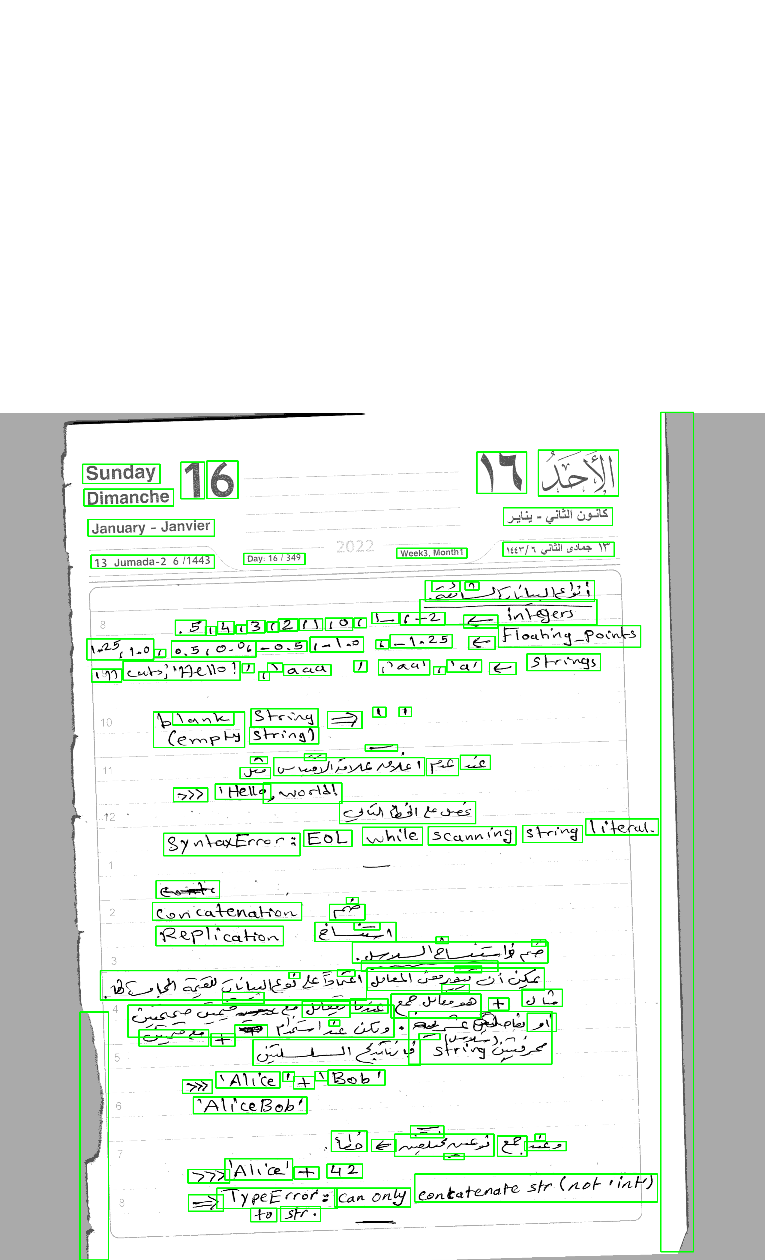


✨ اكتملت العملية! المجموع: 555 سجلات محفوظة في قاعدة بيانات SQLite.


In [ ]:
def process_and_save_data(images_list):
    metadata_file = os.path.join(output_dir, 'labels.csv')
    counter = 0

    with open(metadata_file, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['file_name', 'predicted_text', 'status']) # Added 'status' column

        for pg_idx, img_pil in enumerate(images_list):
            print(f"Processing Page {pg_idx + 1}...")
            img_np = np.array(img_pil)
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
            gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) # Corrected to BGR2GRAY

            # 1. تحسين التباين لخط اليد
            enhanced = cv2.convertScaleAbs(gray, alpha=1.5, beta=-50)

            # 2. التمييز (Thresholding)
            _, binary = cv2.threshold(enhanced, 150, 255, cv2.THRESH_BINARY_INV)

            # 3. دمج الحروف لتكوين كلمات (Kernel أفقي)
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 8))
            dilated = cv2.dilate(binary, kernel, iterations=1)

            # 4. العثور على الكنتورات
            contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            h_img, w_img = gray.shape

            preview = img_bgr.copy()
            for cnt in contours:
                x, y, w, h = cv2.boundingRect(cnt)

                # فلاتر الاستبعاد (تجاهل الجزء العلوي، الهوامش، والضجيج)
                if y < (h_img * 0.15) or x < (w_img * 0.1) or h < 20 or w < 30:
                    continue

                # رسم مربع للمعاينة
                cv2.rectangle(preview, (x, y), (x + w, y + h), (0, 255, 0), 3)

                # قص وحفظ الصورة
                word_crop = img_bgr[y:y+h, x:x+w]
                file_name = f'word_p{pg_idx}_{counter}.png'
                cv2.imwrite(os.path.join(output_dir, file_name), word_crop)

                # تسمية تلقائية سريعة
                try:
                    ocr_res = reader.readtext(word_crop)
                    text = ocr_res[0][1] if ocr_res else ""
                except:
                    text = ""

                writer.writerow([file_name, text, 'yes']) # Changed 'include' to 'yes'
                counter += 1

            # عرض عينة من الصفحة المعالجة
            print(f"تم استخراج {counter} كلمة من هذه الصفحة.")
            cv2_imshow(cv2.resize(preview, (0,0), fx=0.3, fy=0.3))

    print(f"\n✨ اكتملت العملية! المجموع: {counter} صورة محفوظة في Drive.")

# بدء التنفيذ
process_and_save_data(images)